In [2]:
import cv2
import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import argparse

In [57]:
#test to binarize images from OpenAutoscope

In [12]:
def make_binary(input_filename, bg_img_filename, output_filename):
    """
    Convert tiff into a binary image using a background image. Parameters are hard coded.
    For use in ZIM01 and ZIM06 
    Parameters:
    -----------
    input_filename: str,
        Path to the input tiff file
    bg_img_filename: str
        Path to the bg file
    output_filename: str
        Path to the output file
  
    """
    bg_img= tiff.imread(bg_img_filename)

    with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
        with tiff.TiffFile(input_filename, multifile=False) as tif:
            #inside_areas=[]
            for i, page in enumerate(tif.pages):
                #loads the first frame and inverts it
                img=page.asarray()
                #inverts it to have the worm as signakl, bg has low pixel value after this
                img=cv2.bitwise_not(img)
                
                #substrack background
                img=cv2.subtract(img,bg_img)
                
                #median Blur
                img[:] = cv2.medianBlur(img,5)
                
                #apply threshold
                ret, new_img = cv2.threshold(img,20,255,cv2.THRESH_BINARY)
                
                #find contours
                img,contours, hierarchy = cv2.findContours(new_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
                #not in use anymore contours = contours[0] if len(contours) == 2 else contours[1]
                
                #list areas of contours, find MAX, draw contours from MAX area
                areas=[]
                for j in range(0, len(contours)):
                    areas.append(cv2.contourArea(contours[j]))
                worm_contour=np.where(areas==np.asarray(areas).max())
                worm_contour=np.asarray(worm_contour)
                norm = plt.Normalize(worm_contour.min(), worm_contour.max())
                plt.imshow(worm_contour, norm=norm)
                plt.show()
                
                img_contours = np.zeros(img.shape)
                #draws the worm contour, taking into account hierarchy (one level)
                img[:]=cv2.drawContours(img_contours,contours, worm_contour, color=255, thickness=-1, hierarchy=hierarchy, maxLevel=1)
                
                #draw inner part empty
                #for every contour (Again)
                for j in range(0, len(contours)):
                    #if the contours have as a parent worm_contour
                    if hierarchy[0][j][3]==worm_contour:
                        #if the conntours is smaller than 300 sq px, fill it with color 255 (See #18 Labmeeting)
                        #inside_areas.append(cv2.contourArea(contours[j]))
                        
                        #plot a histogram of the inside areas to find the areas you want to discard (this is a function of chosen parameters like threshold)
                        if cv2.contourArea(contours[j])<300:
                            #print(cv2.contourArea(contours[j]))
                            #print('entered')
                            img[:]=cv2.drawContours(img,contours, j, color=255, thickness=-1)
                

                tif_writer.save(img)
                if i ==10: break
             

In [13]:
input_filename='/groups/zimmer/Ulises/wbfm/OpenAutoscope/2021-04-14_15-40-55_worm2-channel-0-bigtiff.btf'
bg_img_filename='/groups/zimmer/Ulises/wbfm/OpenAutoscope/background/MED_2021-04-14_15-40-55_worm2-channel-0-bigtiff_inv_bg.tif'
output_filename='/groups/zimmer/Ulises/wbfm/OpenAutoscope/2021-04-14_15-40-55_worm2-channel-0-bigtiff_binary.btf'

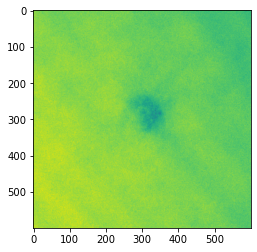

In [5]:
bg_img=tiff.imread(bg_img_path)
plt.imshow(bg_img)

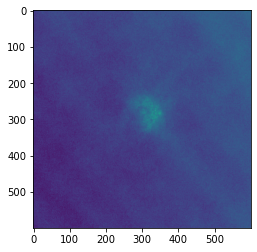

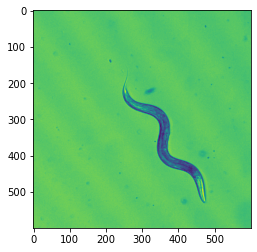

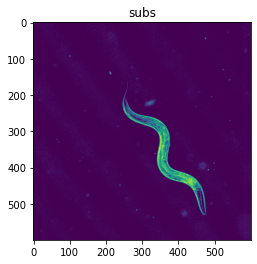

img max:  112 img min:  0


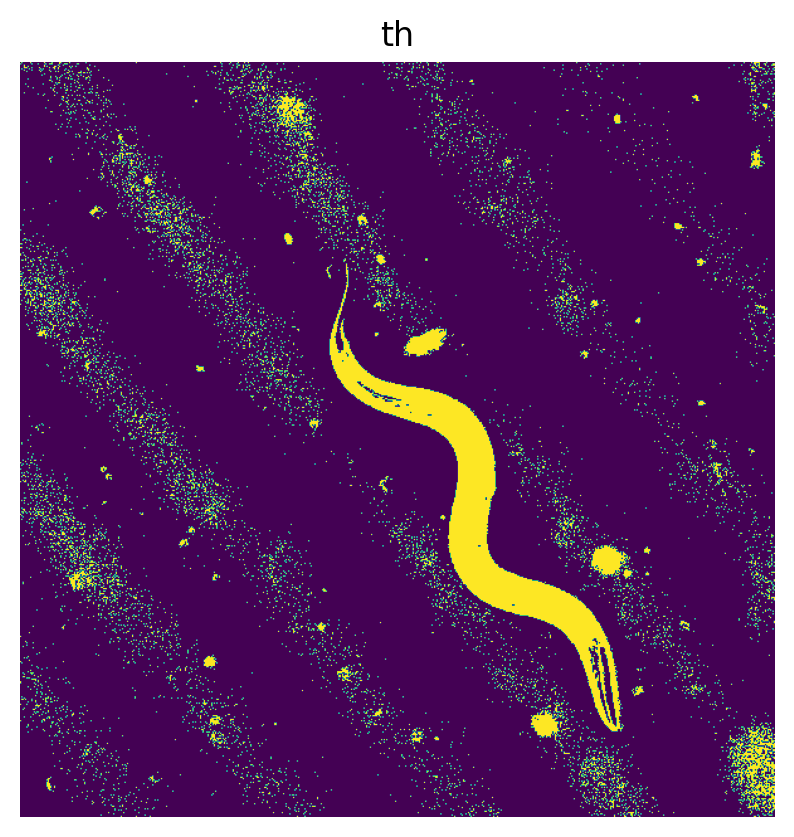

[[5363]]


In [56]:
bg_img= tiff.imread(bg_img_filename)
plt.imshow(bg_img)
plt.show()


with tiff.TiffWriter(output_filename, bigtiff=True) as tif_writer:
    with tiff.TiffFile(input_filename, multifile=False) as tif:
        #inside_areas=[]
        for i, page in enumerate(tif.pages):
            #loads the first frame and inverts it
            img=page.asarray()
            plt.imshow(img)
            plt.show()
            #inverts it to have the worm as signakl, bg has low pixel value after this
            img=cv2.bitwise_not(img)

            #substrack background
            img=cv2.subtract(img,bg_img)
            plt.imshow(img)
            plt.title('subs')

            plt.show()
            #break

            #median Blur
            #img[:] = cv2.medianBlur(img,5)
            print('img max: ',img.max(),'img min: ', img.min())
            #apply threshold
            ret, new_img = cv2.threshold(img,3,255,cv2.THRESH_BINARY)
            plt.figure(figsize=(5,5),dpi=200)
            plt.imshow(new_img)
            plt.title('th')
            plt.axis('off')
            plt.show()

            #find contours
            img,contours, hierarchy = cv2.findContours(new_img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
            #not in use anymore contours = contours[0] if len(contours) == 2 else contours[1]

            #list areas of contours, find MAX, draw contours from MAX area
            areas=[]
            for j in range(0, len(contours)):
                areas.append(cv2.contourArea(contours[j]))
            worm_contour=np.where(areas==np.asarray(areas).max())
            worm_contour=np.asarray(worm_contour)
            print(worm_contour)


            img_contours = np.zeros(img.shape)
            #draws the worm contour, taking into account hierarchy (one level)
            img[:]=cv2.drawContours(img_contours,contours, worm_contour, color=255, thickness=-1, hierarchy=hierarchy, maxLevel=1)

            #draw inner part empty
            #for every contour (Again)
            for j in range(0, len(contours)):
                #if the contours have as a parent worm_contour
                if hierarchy[0][j][3]==worm_contour:
                    #if the conntours is smaller than 300 sq px, fill it with color 255 (See #18 Labmeeting)
                    #inside_areas.append(cv2.contourArea(contours[j]))

                    #plot a histogram of the inside areas to find the areas you want to discard (this is a function of chosen parameters like threshold)
                    if cv2.contourArea(contours[j])<500:
                        #print(cv2.contourArea(contours[j]))
                        #print('entered')
                        img[:]=cv2.drawContours(img,contours, j, color=255, thickness=-1)


            tif_writer.save(img)
            if i ==0: break

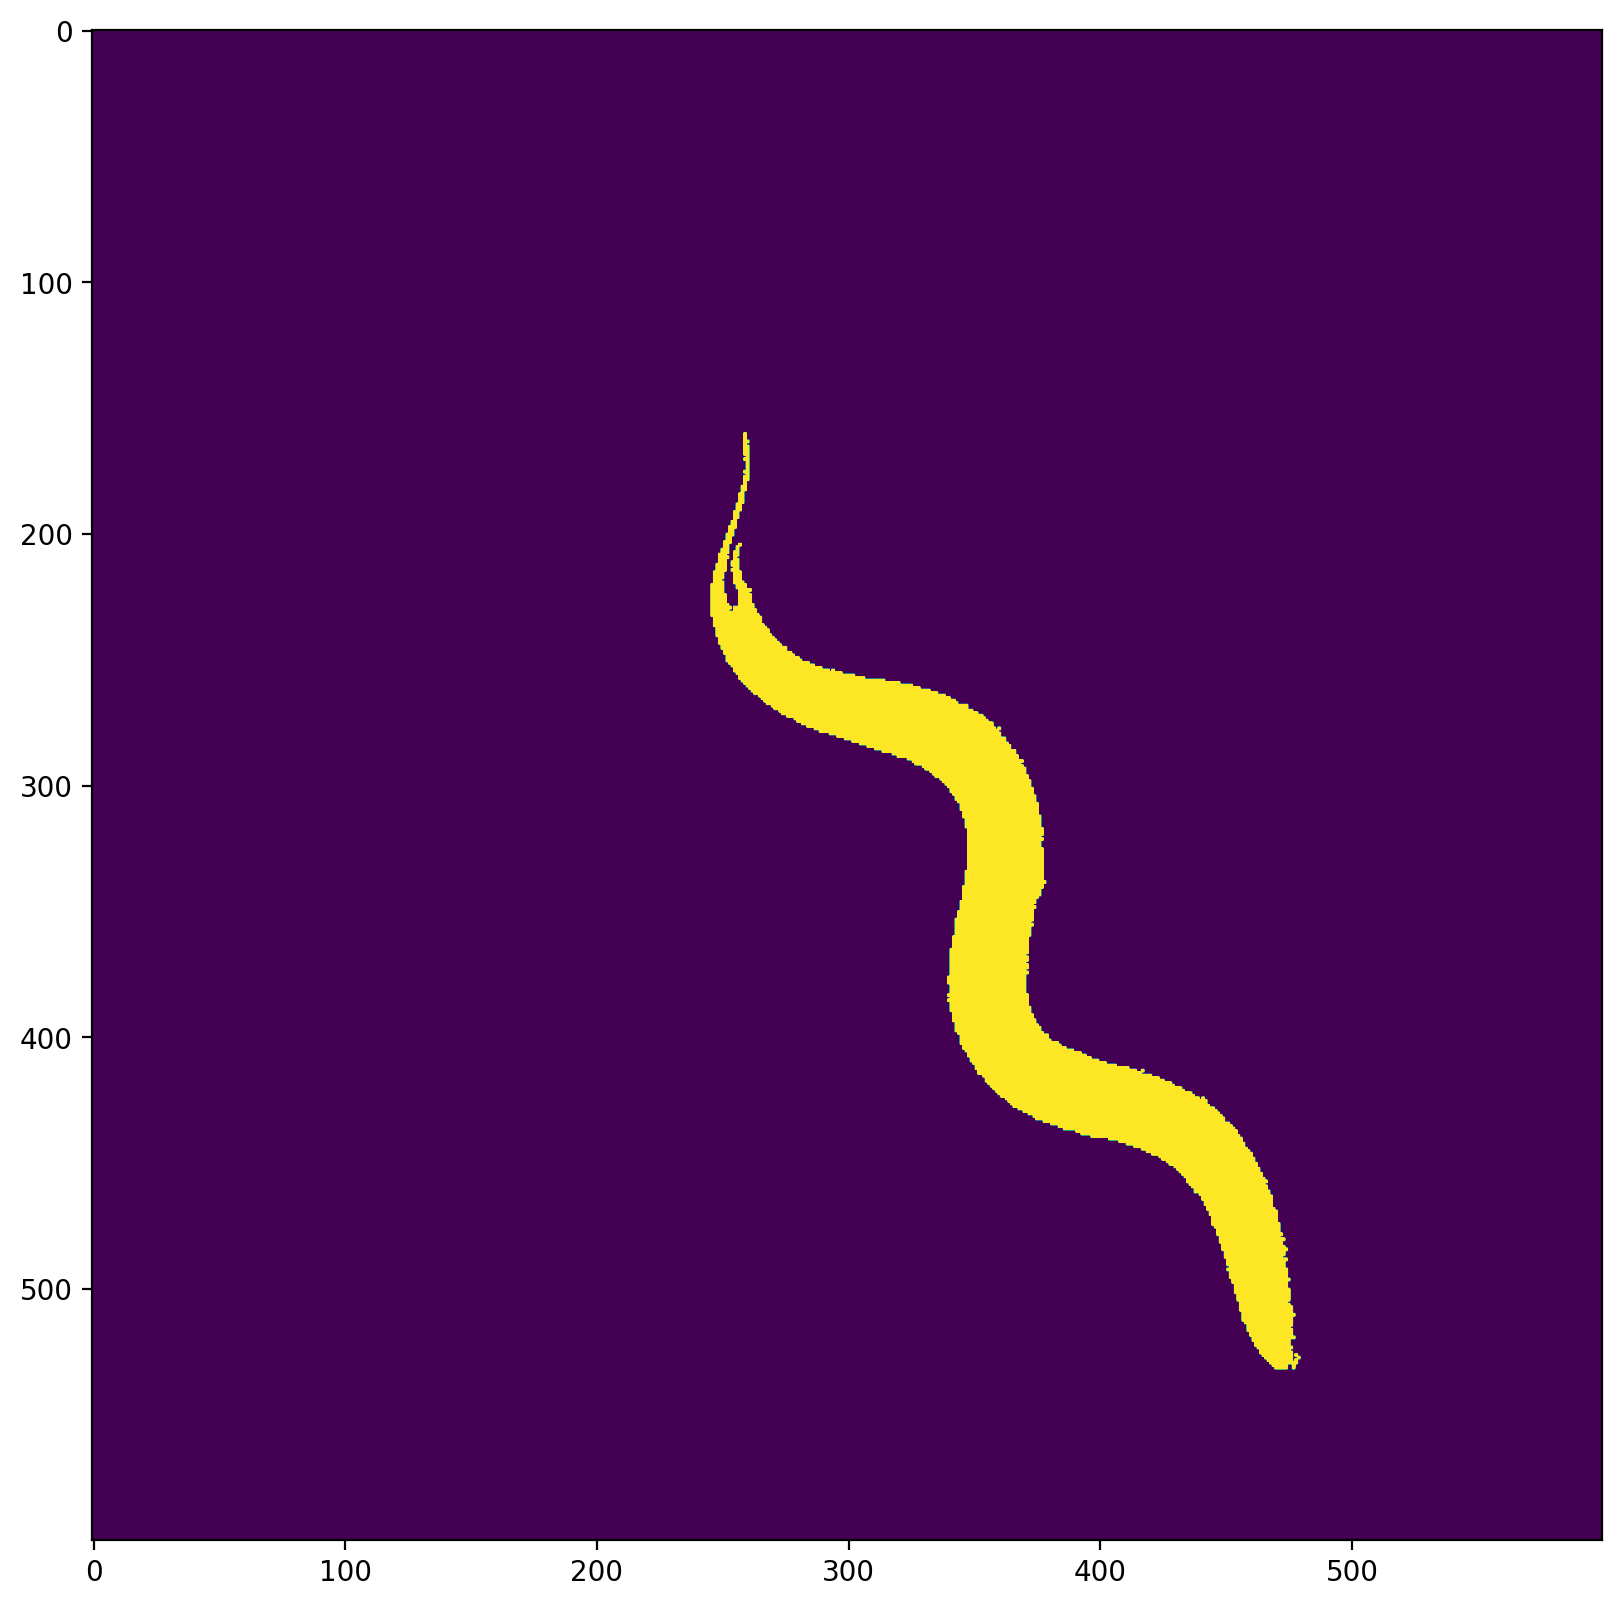

In [52]:
plt.figure(figsize=(10,10),dpi=200)
plt.imshow(img,vmin=0, vmax=50)

In [37]:
worm_contour[0][0]

7

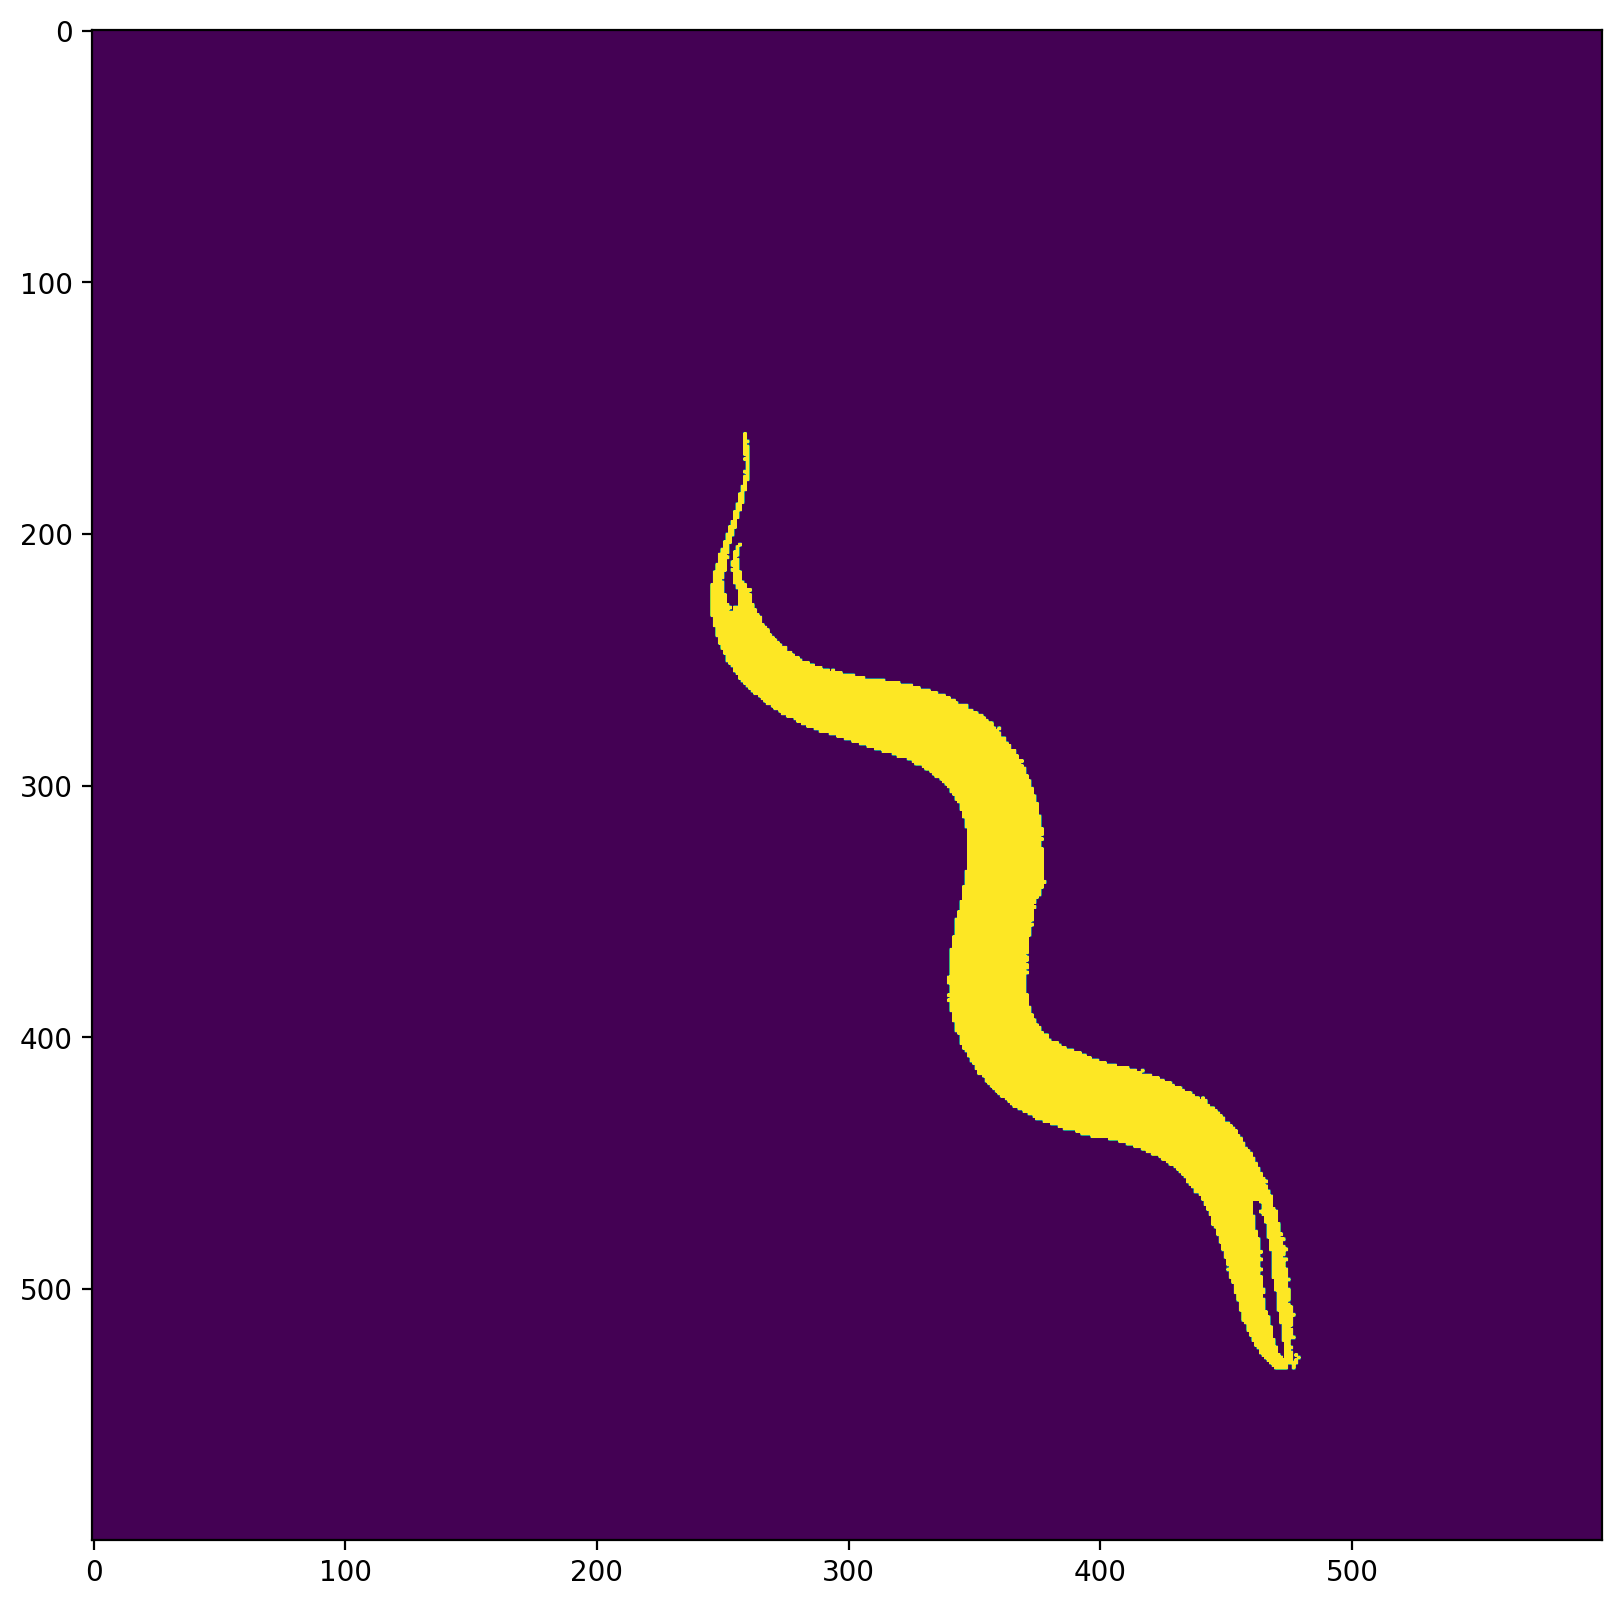

In [50]:
plt.figure(figsize=(10,10),dpi=200)
plt.imshow(img,vmin=0, vmax=50)

In [1]:
input_path='/groups/zimmer/Ulises/wbfm/OpenAutoscope/2021-04-14_15-40-55_worm2-channel-0-bigtiff.btf'
bg_img_path='/groups/zimmer/Ulises/wbfm/OpenAutoscope/background/MED_2021-04-14_15-40-55_worm2-channel-0-bigtiff_bg.tif'
output_path='/groups/zimmer/Ulises/wbfm/OpenAutoscope/2021-04-14_15-40-55_worm2-channel-0-bigtiff_binary.btf'



In [ ]:
make_binary(input_path,bg_img, output_path)